# Complex plane partition

In this notebook we can see how the complex plane is partitioned depending on the parameter $\alpha$, and generate a sample of points for each region so one can create the tests for the algorithm.

In [1]:
from partition import *
import matplotlib.pyplot as plt
import numpy as np
from mpmath import mp
import random 
import math

random.seed(164)

In [2]:
def compute_secondary_params(alpha, tol = 1e-15):
    params = {}

    params['alpha']  = alpha
    params['r0']     = 0.95
    params['delta']  = np.pi*alpha/8
    params['deltat'] = min(np.pi * alpha/8, np.pi * (alpha + 1)/2)

    # Compute r1
    C0 = (1.3)**(1 - alpha)/(np.pi * mp.sin(np.pi * alpha)) # Equation (5.3)
    params['r1'] = float((-2.0 * mp.log(tol/C0))**alpha) # Equation (4.21)

    return params

compute_secondary_params(0.5)

{'alpha': 0.5,
 'r0': 0.95,
 'delta': 0.19634954084936207,
 'deltat': 0.19634954084936207,
 'r1': 8.188434360889147}

In [3]:
def plot_partition(alpha, npoints = 10, fac = 0.7, size = 20):
    params = compute_secondary_params(alpha)
    funcs = [in_G0, in_G1, 
             in_G2, in_G3,
             in_G4, in_G5,
             in_G6]
    colors = ["#00876c", "#6eab79", "#b7ce8f", 
              "#fff1b1", "#f4bb79", "#e98058", 
              "#d43d51"]
    fig, ax = plt.subplots()

    R = 1.2*math.ceil(params['r1'])
    for i in range(npoints):
        theta = random.uniform(0,2*math.pi)
        r = random.uniform(0,R)
        x = math.sqrt(r*R)*math.cos(theta)
        y = math.sqrt(r*R)*math.sin(theta)
        for i in range(len(funcs)):
            if funcs[i](x + y*1j, params):
                ax.scatter(x, y, color = colors[i], s = size)
    
    # Stokes lines
    ax.plot((0, fac*R), (0,  fac*R*np.pi*alpha), color = "#0000ff", linestyle = "--") 
    ax.plot((0, fac*R), (0, -fac*R*np.pi*alpha), color = "#0000ff", linestyle = "--") 
    
    tbl = ax.table(cellText = [" " for i in range(len(funcs))],
             colWidths = [0.1]*len(funcs),
             rowLabels=[f"$G_{i}$" for i in range(len(funcs))],
             bbox=[1.1, 0.42, 0.1,0.3])
    for i in range(len(funcs)):
        tbl.get_celld()[(i,0)].set_facecolor(colors[i])
    
    # set aspect ratio to 1
    ratio = 1.0
    x_left, x_right = ax.get_xlim()
    y_low, y_high = ax.get_ylim()
    ax.set_aspect(abs((x_right-x_left)/(y_low-y_high))*ratio)
    ax.set_xlabel("Re(z)")
    ax.set_ylabel("Im(z)")
    ax.set_title(f"$\\alpha = {alpha:.2f}$")
    
    plt.show()

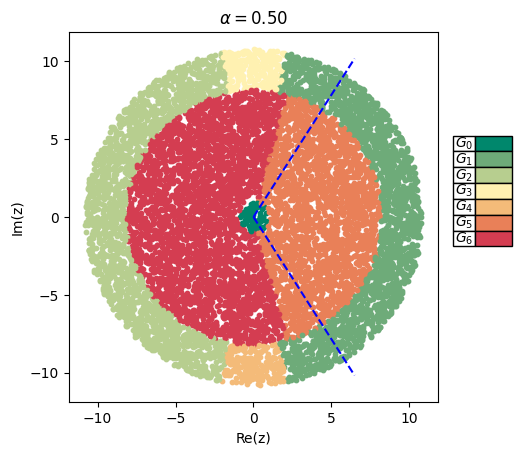

CPU times: user 3min 25s, sys: 2.97 s, total: 3min 28s
Wall time: 3min 28s


In [4]:
%%time
plot_partition(0.5, npoints = 10000, fac = 0.6, size = 10)

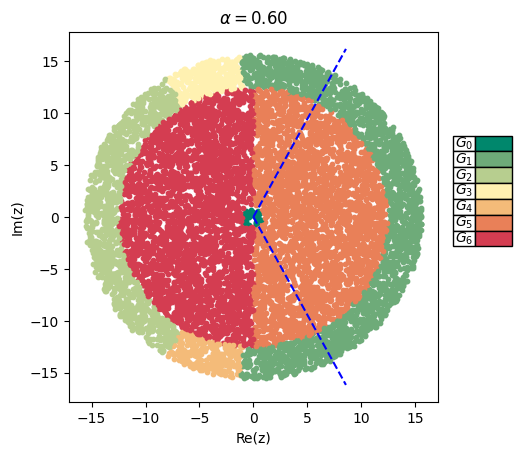

CPU times: user 3min 24s, sys: 2.76 s, total: 3min 27s
Wall time: 3min 27s


In [5]:
%%time
plot_partition(0.6, npoints = 10000, fac = 0.55, size = 10)

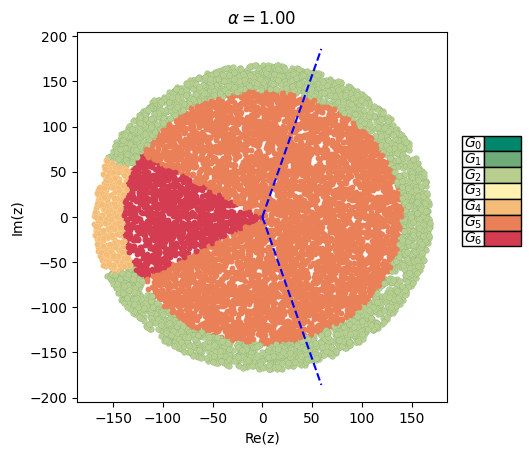

CPU times: user 5min 37s, sys: 5.62 s, total: 5min 43s
Wall time: 5min 44s


In [6]:
%%time
plot_partition(1.0, npoints = 10000, fac = 0.35, size = 10)

You can notice that in fact $G_1 = G_2$ for this case.

In [7]:
%%time
plot_partition(2.0, npoints = 5000, fac = 0.15)

TypeError: float() argument must be a string or a number, not 'mpc'

You can notice that in fact $G_1 = G_2$ for this case too.

In [5]:
def save_partition(alpha, npoints = 5, output = "partition.out"):
    params = compute_secondary_params(alpha)
    R = 1.2*math.ceil(params['r1'])
    funcs = [in_G0, in_G1, 
             in_G2, in_G3,
             in_G4, in_G5,
             in_G6]
    with open(output, "w") as fp:
        fp.write(f"real_part imag_part region\n")
        for i in range(len(funcs)):
            fn = funcs[i]
            count = 0
            while count < npoints:
                theta = random.uniform(0,2*math.pi)
                r = random.uniform(0,R)
                x = math.sqrt(r*R)*math.cos(theta)
                y = math.sqrt(r*R)*math.sin(theta)
                if fn(x+y*1j, params):
                    fp.write(f"{x:+.8e} {y:+.8e} {i:01d}\n")
                    count += 1

def plot_file(fname, size = 10):
    import pandas as pd
    
    df = pd.read_csv(fname, sep = " ")
    colors = ["#00876c", "#6eab79", "#b7ce8f", 
              "#fff1b1", "#f4bb79", "#e98058", 
              "#d43d51"]
    ax = df[df.region == 0].plot.scatter(x = 'real_part', y = 'imag_part', s = size, 
                                         color = colors[0])
    for i in range(1, len(colors)):
        df[df.region == i].plot.scatter(x = 'real_part', 
                                        y = 'imag_part', 
                                        s = size, 
                                        ax = ax,
                                        color = colors[i]) 
    
    tbl = ax.table(cellText = [" " for i in range(len(colors))],
                 colWidths = [0.1]*len(colors),
                 rowLabels=[f"$G_{i}$" for i in range(len(colors))],
                 bbox=[1.1, 0.42, 0.1,0.3])
    for i in range(len(colors)):
        tbl.get_celld()[(i,0)].set_facecolor(colors[i])

CPU times: user 653 ms, sys: 134 ms, total: 787 ms
Wall time: 3.3 s


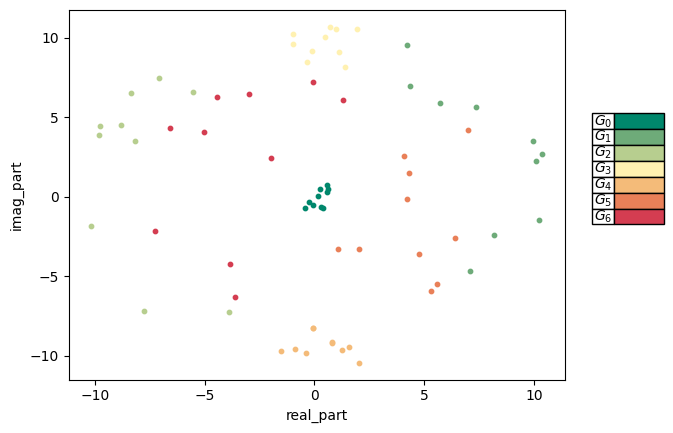

In [9]:
%%time
save_partition(0.5, npoints = 10, output = "partition-alpha=0.5.dsv")
plot_file("partition-alpha=0.5.dsv", size = 10)

CPU times: user 16.9 s, sys: 113 ms, total: 17 s
Wall time: 16.9 s


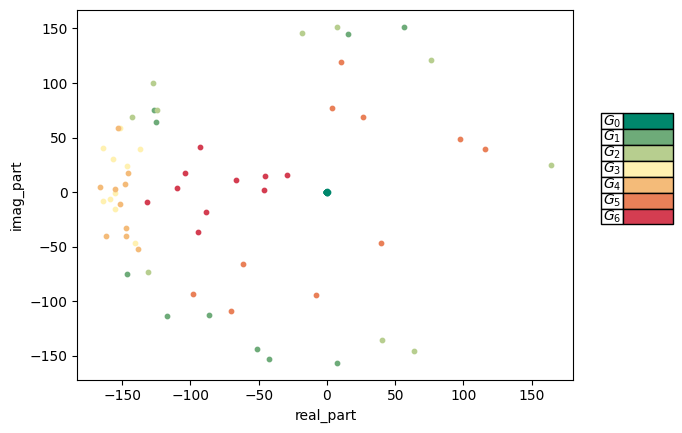

In [6]:
%%time
save_partition(1, npoints = 10, output = "partition-alpha=1.0.dsv")
plot_file("partition-alpha=1.0.dsv", size = 10)

CPU times: user 40.7 s, sys: 117 ms, total: 40.9 s
Wall time: 40.7 s


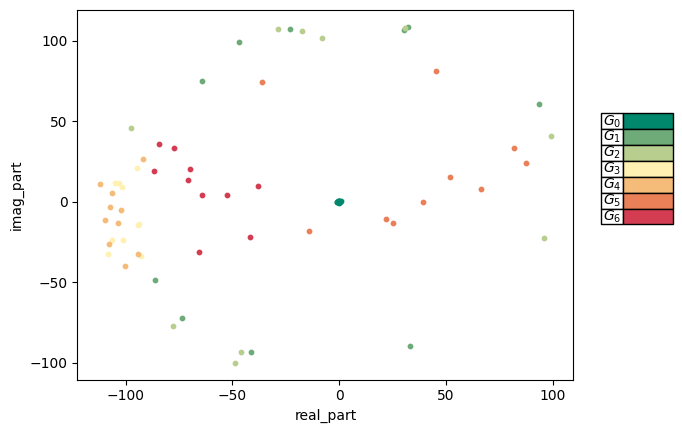

In [11]:
%%time
save_partition(1, npoints = 10, output = "partition-alpha=2.0.dsv")
plot_file("partition-alpha=2.0.dsv", size = 10)